In [270]:
import pandas as pd
import geopandas as gp
from collections import Counter
import pber_functions_v1 as pdv
import os

# Alabama Primary 

In [271]:
gen_24_shps = gp.read_file("./raw-from-source/al_2024_gen_prec/al_2024_gen_cong_prec/al_2024_gen_cong_prec.shp")

In [272]:
gen_24_shps_unsplit = gp.read_file("./raw-from-source/al_2024_gen_prec/al_2024_gen_all_prec/al_2024_gen_all_prec.shp")

In [273]:
gen_24_shps_unsplit = gen_24_shps_unsplit[["UNIQUE_ID","COUNTYFP","County","Precinct","geometry"]].copy(deep = True)
gen_24_shps = gen_24_shps[["UNIQUE_ID","COUNTYFP","County","Precinct","geometry"]].copy(deep = True)

In [274]:
gen_24_shps_unsplit = gen_24_shps_unsplit[gen_24_shps_unsplit["County"]=="Jefferson"]
gen_24_shps = gen_24_shps[gen_24_shps["County"]!="Jefferson"]

In [275]:
gen_24_shps = gp.GeoDataFrame(pd.concat([gen_24_shps, gen_24_shps_unsplit]))

In [276]:
prim_24_results = pd.read_csv("./raw-from-source/al_2024_prim_prec_allocated.csv")
prim_24_results["UNIQUE_ID"] = prim_24_results["County"] + "-:-" + prim_24_results["Precinct"]

In [277]:
races = ['P24A01NO', 'P24A01YES',
       'P24CFJRSTE', 'P24CFJRTAY', 'P24CR2RAND', 'P24CR2RGOV', 'P24CV2RHAN',
       'P24CV2RPAR', 'P24PREDBID', 'P24PREDPHI', 'P24PREDUNC', 'P24PRERBIN',
       'P24PRERCHR', 'P24PRERDES', 'P24PRERHAL', 'P24PRERRAM', 'P24PRERSTU',
       'P24PRERTRU', 'P24PRERUNC', 'P24PSCRCAV', 'P24PSCRMCC', 'PCON01RCAR',
       'PCON01RMOO', 'PCON02DAVE', 'PCON02DBRA', 'PCON02DCOL', 'PCON02DDAN',
       'PCON02DFIG', 'PCON02DGIV', 'PCON02DGRA', 'PCON02DHAR', 'PCON02DLEN',
       'PCON02DPAT', 'PCON02DSIM', 'PCON02RALB', 'PCON02RBRE', 'PCON02RDOB',
       'PCON02RDUP', 'PCON02RGIL', 'PCON02RHAR', 'PCON02RSHE', 'PCON02RTHO',
       'PCON03RBEV', 'PCON03RNEW', 'PCON03RROG', 'PCON04RADE', 'PCON04RHOL',
       'PCON06RMCF', 'PCON06RPAL', 'PCON06RWIL', 'PCON07DDAV', 'PCON07DSEW',
       'PCON07RHOR', 'PCON07RLIT', 'RCON02DDAN', 'RCON02DFIG', 'RCON02RBRE',
       'RCON02RDOB']

In [278]:
prim_24_results["Tot_Votes"] = prim_24_results[races].sum(axis = 1)

In [279]:
prim_24_results = prim_24_results[prim_24_results["Tot_Votes"]!=0]

In [280]:
for race in races:
    prim_24_results.loc[prim_24_results["UNIQUE_ID"]=='Cullman-:-FAIRVIEW FIRE DEPT_ A-K',race] += prim_24_results.loc[prim_24_results["UNIQUE_ID"]=='Cullman-:-FAIRVIEW TOWN HALL L-Z',race].values[0]

prim_24_results = prim_24_results[prim_24_results["UNIQUE_ID"]!='Cullman-:-FAIRVIEW TOWN HALL L-Z']

prim_24_results.loc[prim_24_results["UNIQUE_ID"]=='Cullman-:-FAIRVIEW FIRE DEPT_ A-K',"UNIQUE_ID"] = 'Cullman-:-FAIRVIEW FIRE DEPT TOWN HALL'

In [281]:
prim_24_results[prim_24_results["County"]=="Cullman"][["UNIQUE_ID","Tot_Votes"]].sort_values("UNIQUE_ID")

,UNIQUE_ID,Tot_Votes
490,Cullman-:-ARKADELPHIA FIRE DEPT_,1044
491,Cullman-:-BAILEYTON SR CTR,2401
492,Cullman-:-BALDWIN FAMILY LIFE CTR,1561
493,Cullman-:-BATTLEGROUND FIRE DEPT_,1417
494,Cullman-:-BEAT 8 COMM CTR,705
495,Cullman-:-BERLIN COMM CTR,2444
496,Cullman-:-BETHEL COMM CTR,1031
497,Cullman-:-BETHSADIA FIRE DEPT_,1633
498,Cullman-:-BOLTE WHITE GROVE,1706
499,Cullman-:-BREMEN FIRE DEPT_,2174


In [282]:
def is_split_precinct(district_assignment_list):
    c = Counter([x[0] for x in district_assignment_list])
    greater_than_one = {x:[y[1] for y in district_assignment_list if y[0]==x] for x, count in c.items() if count > 1}
    if len(greater_than_one)==0:
        return 0
    else:
        return greater_than_one
    
def get_level_dist(column_name):
    if column_name[0:3] == "GSL" or column_name[0:3] == "PSL":
        level = "SL"
        dist = column_name[3:6]
    elif column_name[0:3] == "GSU" or column_name[0:3] == "PSU":
        level = "SU"
        dist = column_name[3:5]
    elif column_name[0:3] == "GCO"  or column_name[0:3] == "PCO":
        level = "CON"
        dist = column_name[4:6]
    else:
        print(column_name)
        raise ValueError
    return level,dist

def contains_sldl(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SL":
            return dist_tuple[1]
        
def contains_cong(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "CON":
            return dist_tuple[1]
        
def contains_sldu(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SU":
            return dist_tuple[1]

precinct_mapping_dict = {}
split_precincts_list = {}
for index,row in prim_24_results.iterrows():
    precinct_list = []
    for contest in races:
        if(row[contest]!=0) and ("GSL" in contest or "GCO" in contest or "GSU" in contest or "PCO" in contest or "PSU" in contest or "PSL" in contest):
            precinct_info = get_level_dist(contest)
            if precinct_info not in precinct_list:
                precinct_list.append(get_level_dist(contest))
    is_split = is_split_precinct(precinct_list)
    if (is_split):
        split_precincts_list[row["UNIQUE_ID"]]=is_split
    precinct_mapping_dict[row["UNIQUE_ID"]]=precinct_list
    
cong_check_list = {i:contains_cong(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}

def return_splits(split_dict, level):
    for val in split_dict.keys():
        if level in val:
            return split_dict[level]

def create_splits_dict(level):
    level_splits_dict = {i:return_splits(split_precincts_list[i], level) for i in split_precincts_list.keys() if return_splits(split_precincts_list[i], level) != None }
    return level_splits_dict

cong_splits_dict = create_splits_dict('CON')


## Allocate Votes

In [283]:
prim_24_results[prim_24_results["Precinct"].isin(["ABSENTEE","PROVISIONAL","PROVISONAL","ABSENTEE 1"])]

,UNIQUE_ID,COUNTYFP,County,Precinct,P24A01NO,P24A01YES,P24CFJRSTE,P24CFJRTAY,P24CR2RAND,P24CR2RGOV,...,PCON06RWIL,PCON07DDAV,PCON07DSEW,PCON07RHOR,PCON07RLIT,RCON02DDAN,RCON02DFIG,RCON02RBRE,RCON02RDOB,Tot_Votes


In [284]:
gen_prim_dict = {'Autauga-:-60 MARBURY MIDDLE SCHOOL':'Autauga-:-60 MARBURY MIDDLE SCH',
'Baldwin-:-FAIRHOPE FIRST BAPT':'Baldwin-:-FIRST FAIRHOPE BAPT CH',
'Baldwin-:-GRAHAM CREEK CTR':'Baldwin-:-MIFLIN GRAHAM CREEK CTR',
'Baldwin-:-HOMESTEAD VILLAGE':'Baldwin-:-FAIRHOPE HOMESTEAD VLGE',
'Baldwin-:-MARLOW/FISH RIVER VFD':'Baldwin-:-MARLOW/FISHRIVER VFD',
'Baldwin-:-PROVIDENCE UMC':'Baldwin-:-SPANISH FT PROVIDENCE UMC',
'Baldwin-:-ST_ MARGARET PARISH':'Baldwin-:-ST_ MARGARET PARRISH',
'Bibb-:-LAWLEY COMM CTR_':'Bibb-:-LAWLEY COMM CTR',
'Bibb-:-SIX MILE COMM CTR_':'Bibb-:-SIX MILE COMM CTR',
'Bullock-:-RICHARD B STONE COMPLEX':'Bullock-:-RICHARD B_ STONE COMPLEX',
'Calhoun-:-LEATHERWOOD RD CIVIL':'Calhoun-:-LEATHERWOOD RD CIV_',
'Chambers-:-BUFFALO/LEBANON PRES_':'Chambers-:-BUFFALO',
'Cherokee-:-BROOMTOWN FIRE DEPT':'Cherokee-:-BROOMTOWN FIRE DEPT_',
'Cherokee-:-TUCKERS CHAPEL FIRE DEPT':'Cherokee-:-TUCKERS CHAPEL FIRE DEPT_',
'Clarke-:-FIRST ASSEMBLY OF GOD':'Clarke-:-JACKSON FIRST ASSEMBLY OF GOD',
"Clarke-:-T'VILLE BASHI FIRE":"Clarke-:-T'VILL BASHI FIRE",
"Clarke-:-T'VILLE CITY HALL/CIVIC":"Clarke-:-T'VILL CITY HALL/CIVIC",
'Clay-:-HIPINE FIRE DEPT':'Clay-:-HIPINE FIRE DEPT_',
'Clay-:-IDAHO FIRE DEPT':'Clay-:-IDAHO FIRE DEPT_',
'Cleburne-:-CHULAFINNEE BAPT CH':'Cleburne-:-CHULAFINNEE BAPTIST CHURCH',
'Colbert-:-COUNTY HWY_ DEPT':'Colbert-:-COUNTY HWY_ DEPT_',
'Colbert-:-GATMAN PARK & REC_':'Colbert-:-GATMAN PARK & REC',
'Colbert-:-HELEN KELLER PUBLIC LIBRARY':'Colbert-:-HELEN KELLER LIBRARY',
'Colbert-:-SHEFFIELD FIRE 2ND ST':'Colbert-:-SHEFFIELD FIRE 2ND STN',
'Conecuh-:-HEALTH DEPT':'Conecuh-:-HEALTH DEPT_',
'Conecuh-:-NAZARENE BAPTIST':'Conecuh-:-NAZARENE BAPT_',
'Covington-:-EVANS MEMORIAL CIVIC CTR':'Covington-:-EVANS MEMORIAL CIVIC CTR_',
'Covington-:-LOANGO FIRE DEPT':'Covington-:-LOANGO FIRE DEPT_',
'Covington-:-RED LEVEL FIRE DEPT':'Covington-:-RED LEVEL FIRE DEPT_',
'Covington-:-STRAUGHN HIGH SCH GYM':'Covington-:-STRAUGHN HIGH SCHOOL GYM',
'Covington-:-WING FIRE DEPT':'Covington-:-WING FIRE DEPT_',
'Cullman-:-ARKADELPHIA FIRE DEPT':'Cullman-:-ARKADELPHIA FIRE DEPT_',
'Cullman-:-BAILEYTON SR_ CTR':'Cullman-:-BAILEYTON SR CTR',
'Cullman-:-BATTLEGROUND FIRE DEPT':'Cullman-:-BATTLEGROUND FIRE DEPT_',
'Cullman-:-BETHSADIA FIRE DEPT':'Cullman-:-BETHSADIA FIRE DEPT_',
'Cullman-:-BREMEN FIRE DEPT':'Cullman-:-BREMEN FIRE DEPT_',
'Cullman-:-CRANE HILL FIRE DEPT COMM BLD':'Cullman-:-CRANE HILL FIRE DEPT_ COMM BLD',
'Cullman-:-CULLMAN CO_ HEALTH DEPT':'Cullman-:-CULLMAN CO_ HEALTH DEPT_',
'Cullman-:-FRIENDSHIP METHODIST':'Cullman-:-FRIENDSHIP METHODIST CH',
'Cullman-:-HOLLY POND FIRE DEPT':'Cullman-:-HOLLY POND FIRE DEPT_',
'Cullman-:-JONES CHAPEL FIRE DEPT':'Cullman-:-JONES CHAPEL FIRE DEPT_',
'Cullman-:-JOPPA FIRE DEPT':'Cullman-:-JOPPA FIRE DEPT_',
'Cullman-:-LOGAN FIRE DEPT':'Cullman-:-LOGAN FIRE DEPT_',
'Cullman-:-NEW CANAAN SR_ CTR':'Cullman-:-NEW CANAAN SR CTR',
'Cullman-:-PROVIDENCE FIRE DEPT':'Cullman-:-PROVIDENCE FIRE DEPT_',
'Cullman-:-STOUTS MTN_ BAPTIST':'Cullman-:-STOUTS MTN_ BAPT_',
'Cullman-:-TRIMBLE FIRE DEPT':'Cullman-:-TRIMBLE FIRE DEPT_',
'Dale-:-MIDLAND CITY VOTING HALL':'Dale-:-MIDLAND VOTING HALL',
'Dallas-:-EBENZER MISS_ BAPTIST':'Dallas-:-EBENEZER MISS_ BAPTIST',
'Elmore-:-ASBURY-KENT COMM CTR_':'Elmore-:-ASBURY-KENT COMM',
'Elmore-:-KOWALIGA FIRE DEPT':'Elmore-:-KOWALIGA FIRE DEPT_',
'Elmore-:-RIVER REGION CHURCH':'Elmore-:-RIVER REGION CH',
'Etowah-:-EAST GADSDEN COMM CTR_':'Etowah-:-EAST GADSDEN REC_',
'Fayette-:-FORDS-REHOBETH BAPT_':'Fayette-:-FORDS-REHOBETH BAPT',
'Franklin-:-BELGREEN FIRE DEPT':'Franklin-:-BELGREEN FIRE DEPT_',
'Franklin-:-LAWLERS FIRE DEPT':'Franklin-:-LAWLERS FIRE DEPT_',
'Franklin-:-MT_ STAR STORE':'Franklin-:-MT_ STAR HILLS SCHOOL',
'Greene-:-BOLIGEE FIRE DEPT':'Greene-:-BOLIGEE FIRE DEPT_',
'Greene-:-JENA FIRE DEPT':'Greene-:-JENA FIRE DEPT_',
'Greene-:-KNOXVILLE FIRE DEPT':'Greene-:-KNOXVILLE FIRE DEPT_',
'Greene-:-MANTUA FIRE DEPT':'Greene-:-MANTUA FIRE DEPT_',
'Greene-:-UNION FIRE DEPT':'Greene-:-UNION FIRE DEPT_',
'Houston-:-COWARTS BAPT CH':'Houston-:-COWARTS BAPTIST',
'Houston-:-LIBERTY BAPTIST CHURCH':'Houston-:-LIBERTY BAPTIST CH',
'Lawrence-:-CADDO FIRE DEPT 33-1':'Lawrence-:-CADDO FIRE DEPT_ 33-1',
'Lawrence-:-CHALYBEATE FIRE DEPT17-1':'Lawrence-:-CHALYBEATE FIRE DEPT 17-1',
'Lawrence-:-HILLBORO FIRE DEPT 4-1':'Lawrence-:-HILLBORO FIRE DEPT_ 4-1',
'Lawrence-:-LANDERSVILLE METH_ 12-1':'Lawrence-:-LANDERSVILLE M_C_ 12-1',
'Lawrence-:-LAWRENCE HEALTH DEPT19-1':'Lawrence-:-LAWRENCE HEALTH DEPT 19-1',
'Lawrence-:-MT MORIAH METH_15-1 21-1':'Lawrence-:-MT MORIAH M_C_ 15-1 21-1',
'Lawrence-:-PILGRAM MISS_ BAPT_ 18-1':'Lawrence-:-PILGRAM MISS_ BAPT 18-1',
'Lawrence-:-RED BANK FIRE DEPT 3-1':'Lawrence-:-RED BANK FIRE DEPT_ 3-1',
'Lawrence-:-SPEAKE FIRE DEPT 28-1':'Lawrence-:-SPEAKE FIRE DEPT_ 28-1',
'Lee-:-AUBURN COMM CH':'Lee-:-AUBURN COMM CHURCH',
'Lee-:-BEAUREGARD VFD MARVYN 00100_00':'Lee-:-BEAUREGARD VFD MARVYN',
'Lee-:-BEULAH VFD #3':'Lee-:-BEULAH FIRE #3',
'Lee-:-BEULAH HIGH SCH':'Lee-:-BEULAH HIGH',
'Lee-:-CH OF THE HIGHLANDS':'Lee-:-CHURCH OF THE HIGHLANDS',
'Lee-:-DENSON DRIVE REC_ CTR':'Lee-:-DENSON DR_ REC_ CTR',
'Lee-:-EMBRACE CHRUCH':'Lee-:-EMBRACE CHURCH',
'Lee-:-GLENWOOD SCH_ GYM':'Lee-:-GLENWOOD SCHOOL GYM',
'Lee-:-LEE CO LEARNING CTR':'Lee-:-LEE CO_ LEARNING CTR',
'Lee-:-MT_ ZION FAMILY CTR_':'Lee-:-MT_ ZION ENRICHMENT CTR',
'Lee-:-PARKWAY BAPT_ CH':'Lee-:-PARKWAY BAPT CHURCH',
'Lee-:-PINE GROVE CH':'Lee-:-PINE GROVE CHURCH',
'Lee-:-SMITHS JR_ HIGH':'Lee-:-SMITHS JR HIGH',
'Lee-:-WAVERLY LOCAL RESTURANT':'Lee-:-WAVERLY LOCAL RESTAURANT',
'Limestone-:-ARDMORE SENIOR CTR_':'Limestone-:-ARDMORE SR_ CENTER',
'Limestone-:-ELKMONT FIRE DEPT':'Limestone-:-ELKMONT FIRE DEPT_',
'Limestone-:-PLEASANT GROVE FIRE DEPT':'Limestone-:-PLEASANT GROVE FIRE DEPT_',
'Limestone-:-WEST LIMESTONE FIRE DEPT':'Limestone-:-WEST LIMESTONE FIRE DEPT_',
'Madison-:-A & M UNIVERSITY NEW GYM':'Madison-:-A & M UNIVERSITY GYM',
'Madison-:-CAVALRY HILL COMMUNITY CTR':'Madison-:-CALVARY HILL FRIENDSHIP CTR_',
'Madison-:-DAYSTAR CH-MADISON':'Madison-:-DAYSTAR CH - MADISON',
'Madison-:-GURLEY REC_ CTR_':'Madison-:-GURLEY REC CTR',
'Madison-:-LEWIS CHAPEL C_ P_ CH':'Madison-:-LEWIS CHAPEL C_P_ CH',
'Madison-:-ST_ MATTHEW PB CHURCH':'Madison-:-ST_ MATTHEWS PB CH',
'Marengo-:-RANGELINE BAPTIST CH':'Marengo-:-RANGELINE BAPTISIT CH',
'Marion-:-KIMBROUGH CRAFT COMM N_& S_':'Marion-:-KIMBROUGH CRAFT COMM N&S',
'Marshall-:-ALBERTVILLE 1ST BAPT CH':'Marshall-:-1ST BAPTIST CHURCH',
'Marshall-:-BOAZ PARK & REC':'Marshall-:-BOAZ PARK & REC_',
'Marshall-:-JAYBIRD/DIST 4 CO_ SHOP':'Marshall-:-DISTRICT 4 CO_ SHOP',
'Marshall-:-FRIENDSHIP/PINE GROVE COMM CTR':'Marshall-:-PINE GROVE COMM_ CTR',
'Marshall-:-MACK TRANSPORT':'Marshall-:-C & C ASPHALT',
'Marshall-:-MT_ CALVARY BAPTIST':'Marshall-:-MT CALVARY BAPTIST',
'Marshall-:-MT_ HEBRON FIRE':'Marshall-:-MT_ HEBRON FIRE DEPT_',
'Mobile-:-1ST BAPTIST CH OF WILMER':'Mobile-:-1ST BAPTIST CH WILMER',
'Mobile-:-BAKER HIGH SCH':'Mobile-:-BAKER HIGH SCHOOL',
'Mobile-:-BETHEL BAPTIST CH':'Mobile-:-BETHEL BAPT CH',
'Mobile-:-BISHOP STATE':'Mobile-:-BISHOP STATE COMM COLLEGE',
'Mobile-:-BOYS & GIRLS CLUB OF MOBILE':'Mobile-:-BOYS & GIRLS CLUB MOBLIE',
'Mobile-:-BURNS MIDDLE SCHOOL':'Mobile-:-BURNS MIDDLE SCH',
'Mobile-:-BURROUGHS ELEM':'Mobile-:-BURROUGHS ELEMENTARY',
'Mobile-:-COLLIER ELEM':'Mobile-:-COLLIER ELEMENTARY',
'Mobile-:-COLLINS RHODES ELEM':'Mobile-:-COLLINS-RHODES ELEMENTARY',
'Mobile-:-CYPRESS SHORES BAPTIST':'Mobile-:-CYPRESS SHORES BAPT',
'Mobile-:-DODGE ELEM':'Mobile-:-DODGE ELEMENTARY',
'Mobile-:-EICHOLD MERTZ ELEM':'Mobile-:-EICHOLD MERTZ ELEMENTARY',
'Mobile-:-E_ R_ DICKSON ELEM':'Mobile-:-E_R_ DICKSON ELEMENTARY',
'Mobile-:-FOREST HILL ELEM':'Mobile-:-FOREST HILL ELEMENTARY',
'Mobile-:-FRIENDSHIP BAPTIST CH':'Mobile-:-FRIENDSHIP BAPT',
'Mobile-:-FRIENDSHIP  MISSIONARY':'Mobile-:-FRIENDSHIP MISSIONARY BAPT',
'Mobile-:-HOLLINGERS ISLAND ELEM':'Mobile-:-HOLLINGER ISLAND ELEM_',
'Mobile-:-HOLLOWAY ELEM':'Mobile-:-HOLLOWAY ELEMENTARY',
'Mobile-:-JAMES SEALS JR_ PARK & REC':'Mobile-:-JAMES SEALS JR_ PARK & REC CTR',
'Mobile-:-J_C_ DAVIS AUDITORIUM':'Mobile-:-J_C_DAVIS AUDITORIUM',
'Mobile-:-J_E_ TURNER ELEM':'Mobile-:-J_E_TURNER ELEMENTARY',
'Mobile-:-KATE SHEPARD ELEM':'Mobile-:-KATE SHEPARD ELEMENTARY',
'Mobile-:-LEINKAUF ELEM':'Mobile-:-LEINKAUF ELEMENTARY',
'Mobile-:-MAGNOLIA SPRINGS BAPTIST':'Mobile-:-MAGNOLIA SPRINGS BAPT',
'Mobile-:-MEADOWLAKE ELEM':'Mobile-:-MEADOWLAKE ELEMENTARY',
'Mobile-:-PALMER PILLANS MIDDLE':'Mobile-:-PALMER PILLANS MIDDLE SCH',
'Mobile-:-PINE GROVE MISSIONARY BAPT CH':'Mobile-:-PINE GROVE MISSIONARY BAPT',
'Mobile-:-REVELATION MISSIONARY':'Mobile-:-REVELATION MISSIONARY BAPT',
'Mobile-:-ROBBINS ELEM':'Mobile-:-ROBBINS ELEMENTARY',
'Mobile-:-SEMMES FIRST BAPTIST':'Mobile-:-SEMMES 1ST BAPT CH',
'Mobile-:-SHELTON BEACH RD BAPT':'Mobile-:-SHELTON BEACH RD_ BAPT',
'Mobile-:-ST_ MICHAEL CATHOLIC CH':'Mobile-:-ST MICHAEL CATHOLIC CH',
'Mobile-:-ST_ PHILIP NERI CATHOLIC':'Mobile-:-ST PHILIP NERI CATHOLIC',
'Mobile-:-ST_ ELMO ELEM':'Mobile-:-ST_ ELMO ELEMENTARY',
'Mobile-:-ST_ PAULS EPISCOPAL CH':"Mobile-:-ST_ PAUL'S EPISCOPAL CH",
'Mobile-:-SURGE CHURCH':'Mobile-:-SURGE CH',
'Mobile-:-UNION BAPTIST CHURCH':'Mobile-:-UNION BAPT CH',
'Monroe-:-BETHANY BAPT (BURNT CORN)':'Monroe-:-BETHANY BAPT CH',
'Monroe-:-BUENA VISTA VREN FD':'Monroe-:-BUENA VISTA VRENDEN',
'Monroe-:-CHRYSLER ELISKA':'Monroe-:-CHRYSLER / ELISKA',
'Monroe-:-LOWER PEACH TREE':'Monroe-:-L PEACHTREE PACK BEND',
'Monroe-:-OAK GROVE BAPT CH':'Monroe-:-OAK GROVE',
'Monroe-:-PERDUE HILL MAS_ LODGE':'Monroe-:-PERDUE HILL MASONIC',
'Monroe-:-WAINWRIGHT FINCH FD':'Monroe-:-WAINWRIGHT FINCHBURG FD',
'Montgomery-:-203 HAYNEVILLE RD COMM CTR':'Montgomery-:-203 HAYNEVILLE RD COMM',
'Montgomery-:-205 SOUTHLAWN BAPT':'Montgomery-:-205 SOUTHLAWN BAPT CH',
'Montgomery-:-208 STONETANK ANTIOCH BAPT':'Montgomery-:-208 STONETANK BAPT CH',
'Montgomery-:-210 PINTLALA FIRE DEPT':'Montgomery-:-210 PINTLALA FIRE',
'Montgomery-:-301 DALRAIDA CH CHRIST':'Montgomery-:-301 DALRAIDA BAPTIST CH',
'Montgomery-:-304 OLD ELAM BAPT':'Montgomery-:-304 OLD ELAM BAPT CH',
'Montgomery-:-305 FRAZER CHURCH':'Montgomery-:-305 FRAZER METHODIST',
'Montgomery-:-408 HIGHLAND GARDEN CC':'Montgomery-:-408 HIGHLAND GARDEN COMM CTR',
'Montgomery-:-506 DAVIS CROSSRODS':'Montgomery-:-506 DAVIS CROSSRDS',
'Morgan-:-DECATUR FIRE & POLICE TRNG CTR':'Morgan-:-DECATUR FIRE & POILCE TRNG CTR',
'Morgan-:-FORT DECATUR REC CTR':'Morgan-:-FORT DECATUR REC',
'Morgan-:-JOHN J SPARKMAN CIVIC':'Morgan-:-JOHN J SPARKMAN CIVIC CTR',
'Morgan-:-MACEDONIA C P CHURCH':'Morgan-:-MACEDONIA C P CH',
'Morgan-:-MASSEY FIRE DEPT':'Morgan-:-MASSEY FIRE DEPARTMENT',
'Pike-:-ANTIOCH CH OF CHRIST':'Pike-:-ANTIOCH CH',
'Pike-:-CHINA GROVE CO_ BLDG_':'Pike-:-CHINA GROVE CO BLDG',
'Pike-:-FIRST BAPT CHURCH':'Pike-:-FIRST BAPT CH',
'Pike-:-NEEDMORE VOTING CTR #1':'Pike-:-NEEDMOREVOTING CTR #1',
'Pike-:-OAK BOWERY CH OF CHRIST':'Pike-:-OAK BOWERY CH',
'Pike-:-TARENTUM COMM CLUBHOUSE':'Pike-:-TARENTUM COMM CLUB',
'Randolph-:-FOSTERS CROSSROADS':'Randolph-:-FOSTERS XR',
'Randolph-:-WOODLAND FIRE DEPT':'Randolph-:-WOODLAND FIRE DEPT_',
'Russell-:-MT OLIVE SUNDERLAND VFD':'Russell-:-MT_ OLIVE SUNDERLAND VFD',
'Shelby-:-BEULAH BAPTIST CHURCH':'Shelby-:-BEULAH BAPTIST CH',
'Shelby-:-CALERA BAPTIST CHURCH':'Shelby-:-CALERA BAPTIST CH',
'Shelby-:-DOUBLE OAK CH- CHELSEA':'Shelby-:-DOUBLE OAK CH-CHELSEA',
'Shelby-:-KINGWOOD CHURCH':'Shelby-:-KINGWOOD CH',
'Shelby-:-MCCHESNEY STUDENT CTR_':'Shelby-:-McCHESNEY STUDENT CTR',
'Shelby-:-WESTWOOD BAPTIST CH':'Shelby-:-WESTWOOD BAPT_ CHURCH',
'St. Clair-:-PELL CITY BOYS&GIRLS CLUB':'St. Clair-:-BOYS&GIRLS CLUB-PELL CITY',
'St. Clair-:-COOK SPRGS BAPTIST CH':'St. Clair-:-COOK SPRGS BAPT CH',
'Talladega-:-STEMLEY VFD+':'Talladega-:-STEMLEY VFD',
'Talladega-:-EASTABOGA BAPTIST CH':'Talladega-:-EASTABOGO BAPTIST CH',
'Talladega-:-RUSSELL CHAPEL BAPT':'Talladega-:-RUSSELL CHAPEL BAPT CH',
'Tallapoosa-:-REELTOWN FIRE DEPT':'Tallapoosa-:-REELTOWN FIRE DEPT_',
'Tuscaloosa-:-FLATWOODS BAPT CH':'Tuscaloosa-:-FLATWOODS BAPT',
'Tuscaloosa-:-GRACE PRES_ CHURCH':'Tuscaloosa-:-GRACE PRESBYTERIAN CH',
'Tuscaloosa-:-NEW ZION MISSIONARY CH':'Tuscaloosa-:-NEW ZION MISSIONARY',
'Tuscaloosa-:-STILLMAN COLLEGE WYNN BLDG':'Tuscaloosa-:-STILLMAN COLLEGE',
'Tuscaloosa-:-VANCE ACTIVITY BLDG':'Tuscaloosa-:-VANCE ACTIVITY BLDG_',
'Tuscaloosa-:-WESLEY CHAPEL COMM CTR':'Tuscaloosa-:-WESLEY METHODIST CH',
'Tuscaloosa-:-YELLOW CREEK BAPT CH':'Tuscaloosa-:-YELLOW CRK BAPT CH',
'Tuscaloosa-:-COTTONDALE':'Tuscaloosa-:-COTTONDALE METHODIST CH',
'Walker-:-ARGO FIRE DEPT':'Walker-:-ARGO FIRE DEPT_',
'Walker-:-JASPER HOUSING AUTH_ GYM':'Walker-:-JASPER HOUSING AUTH_',
'Walker-:-PINEYWOODS FIRE DEPT':'Walker-:-PINEYWOODS FIRE DEPT_',
"Walker-:-RICES CHAPEL CH":"Walker-:-RICE'S CHAPEL CH",
'Walker-:-TUTWILER FIRE DEPT':'Walker-:-TUTWILER FIRE DEPT_',
'Wilcox-:-F_S_ ERVIN ELEM':'Wilcox-:-F_S_ ERVIN ELEM_',
'Winston-:-ARLEY FIRE DEPT':'Winston-:-ARLEY FIRE DEPT_',
'Winston-:-ASHRIDGE FIRE DEPT':'Winston-:-ASHRIDGE FIRE DEPT_',
'Winston-:-BLACK POND FIRE DEPT':'Winston-:-BLACK POND FIRE DEPT_',
'Winston-:-HELICON FIRE DEPT':'Winston-:-HELICON FIRE DEPT_',
'Winston-:-LYNN COMM CENTER':'Winston-:-LYNN OLD CITY HALL',
'Winston-:-MORELAND FIRE DEPT':'Winston-:-MORELAND FIRE DEPT_',
'Winston-:-NATURAL BRIDGE COMM CENTER':'Winston-:-NATURAL BRIDGE COMM_ CTR_',
'Winston-:-NESMITH CHURCH':'Winston-:-NESMITH CH',
'Winston-:-UPSHAW FIRE DEPT':'Winston-:-UPSHAW FIRE DEPT_',
'Bibb-:-EOLINE FIRE DEPT_':'Bibb-:-EOLINE FIRE DEPT',
'Bibb-:-GREENPOND FIRE DEPT_':'Bibb-:-GREENPOND FIRE DEPT',
'Bibb-:-LAWLEY COMM_ CTR_':'Bibb-:-LAWLEY COMM CTR',
'Bibb-:-SIX MILE COMM_ CTR_':'Bibb-:-SIX MILE COMM CTR',
'Butler-:-CHAPMAN POST OFFICE':'Butler-:-CHAPMAN VTG HOUSE',
'Calhoun-:-CHOCCOLOCCO COMM_ CTR':'Calhoun-:-CHOCCOLOCCO COMM CTR',
'Clarke-:-GOSPORT FIRE-(CONG-02)':'Clarke-:-GOSPORT FIRE 61_2 CONG 2',
'Clarke-:-GROVE HILL TOWN HALL':'Clarke-:-GROVE HILL CITY HALL',
'Clarke-:-JACKSON CITY HALL-(CONG-02)':'Clarke-:-JACKSON CITY HALL CONG 2',
'Clarke-:-JACKSON CITY HALL-(CONG-07)':'Clarke-:-JACKSON CITY HALL CONG 7',
'Clarke-:-JACKSON DOWNTOWN-(CONG-02)':'Clarke-:-JACKSON DOWNTOWN CONG 2',
'Clarke-:-JACKSON DOWNTOWN-(CONG-07)':'Clarke-:-JACKSON DOWNTOWN CONG 7',
'Clarke-:-MORNING STAR-(CONG-07)':'Clarke-:-MORNING STAR 111_1 CONG7',
'Clarke-:-MORNING STAR-(CONG-02)':'Clarke-:-MORNING STAR CONG 2',
'Clarke-:-NETTLESBORO-(CONG-07)':'Clarke-:-NETTLESBORO 112_1 CONG7',
'Clarke-:-NETTLESBORO-(CONG-02)':'Clarke-:-NETTLESBORO 112_2 CONG2',
'Clarke-:-WALKER SPRNGS-(CONG-02)':'Clarke-:-WALKER SPRNGS 41_1 CONG2',
'Clarke-:-WALKER SPRNGS-(CONG-07)':'Clarke-:-WALKER SPRNGS 41_2 CONG7',
'Dale-:-EWELL BIBLE BAPTIST':'Dale-:-EWELL FIRE',
'Elmore-:-ASBURY-KENT COMM_ CTR_':'Elmore-:-ASBURY-KENT COMM_',
'Etowah-:-EAST GADSDEN COMM_ CTR_':'Etowah-:-EAST GADSDEN REC_',
'Lee-:-AUBURN COMM_ CH':'Lee-:-AUBURN COMM_ CHURCH',
'Mobile-:-BAYOU LA BATRE COMM_ CTR':'Mobile-:-BAYOU LA BATRE COMM CTR',
'Mobile-:-BURROUGHS ELEM_':'Mobile-:-BURROUGHS ELEMENTARY',
'Mobile-:-COVENANT ACADEMY, INC-(CONG-01)':'Mobile-:-COVENANT ACADEMY CONG 1',
'Mobile-:-COVENANT ACADEMY, INC-(CONG-02)':'Mobile-:-COVENANT ACADEMY CONG 2',
'Mobile-:-CRAIGHEAD ELEM-(CONG-01)':'Mobile-:-CRAIGHEAD ELEMENTARY CONG 1',
'Mobile-:-CRAIGHEAD ELEM-(CONG-02)':'Mobile-:-CRAIGHEAD ELEMENTARY CONG 2',
'Mobile-:-DODGE ELEM_':'Mobile-:-DODGE ELEMENTARY',
'Mobile-:-HOLY NAME OF JESUS CH-(CONG-01)':'Mobile-:-HOLY NAME OF JESUS CH CONG 1',
'Mobile-:-HOLY NAME OF JESUS CH-(CONG-02)':'Mobile-:-HOLY NAME OF JESUS CH CONG 2',
'Mobile-:-J_E_ TURNER ELEM_':'Mobile-:-J_E_TURNER ELEMENTARY',
'Mobile-:-MEADOWLAKE ELEM_':'Mobile-:-MEADOWLAKE ELEMENTARY',
'Mobile-:-MEMORIAL BAPTIST CH-(CONG-01)':'Mobile-:-MEMORIAL BAPT CH CONG 1',
'Mobile-:-MEMORIAL BAPTIST CH-(CONG-02)':'Mobile-:-MEMORIAL BAPT CH CONG 2',
'Mobile-:-McDAVID JONES ELEM-(CONG-01)':'Mobile-:-McDAVID JONES ELEM CONG 1',
'Mobile-:-McDAVID JONES ELEM-(CONG-02)':'Mobile-:-McDAVID JONES ELEM CONG 2',
'Mobile-:-SEMMES COMM CTR':'Mobile-:-SEMMES COMM_ CTR',
'Mobile-:-ST_ ELMO ELEM_':'Mobile-:-ST_ ELMO ELEMENTARY',
'Mobile-:-THE GRAND HALL-(CONG-01)':'Mobile-:-THE GRAND HALL CONG 1',
'Mobile-:-THE GRAND HALL-(CONG-02)':'Mobile-:-THE GRAND HALL CONG 2',
'Mobile-:-TILLMANS CORNER COMM_ CTR-(CONG-01)':"Mobile-:-TILLMAN'S CORNER COMM CTR CONG 1",
'Mobile-:-TILLMANS CORNER COMM_ CTR-(CONG-02)':"Mobile-:-TILLMAN'S CORNER COMM CTR CONG 2",
'Mobile-:-TURNERVILLE BAPTIST CH-(CONG-01)':'Mobile-:-TURNERVILLE BAPT CH CONG 1',
'Mobile-:-TURNERVILLE BAPTIST CH-(CONG-02)':'Mobile-:-TURNERVILLE BAPT CH CONG 2',
'St. Clair-:-RIVERSIDE COMM CTR':'St. Clair-:-RIVERSIDE COMM_ CTR',
'Talladega-:-COUNTY LINE VFD-(CONG-03)':'Talladega-:-COUNTY LINE VFD CONG 3',
'Talladega-:-COUNTY LINE VFD-(CONG-06)':'Talladega-:-COUNTY LINE VFD CONG 6',
'Talladega-:-FAYETTEVILLE UMC-(CONG-03)':'Talladega-:-FAYETTEVILLE UMC CONG 3',
'Talladega-:-FAYETTEVILLE UMC-(CONG-06)':'Talladega-:-FAYETTEVILLE UMC CONG 6',
'Tuscaloosa-:-ALBERTA BAPT CH-(CONG-04)':'Tuscaloosa-:-ALBERTA BAPT CH CNG4',
'Tuscaloosa-:-ALBERTA BAPT CH-(CONG-07)':'Tuscaloosa-:-ALBERTA BAPT CH CNG7',
'Tuscaloosa-:-BOBBY MILLER ACTIVITY-(CONG-04)':'Tuscaloosa-:-BOBBY MILLER ACTIVITY CONG4',
'Tuscaloosa-:-BOBBY MILLER ACTIVITY-(CONG-07)':'Tuscaloosa-:-BOBBY MILLER ACTIVITY CONG7',
'Tuscaloosa-:-COVENANT CH-(CONG-04)':'Tuscaloosa-:-COVENANT CH CONG4',
'Tuscaloosa-:-COVENANT CH-(CONG-07)':'Tuscaloosa-:-COVENANT CH CONG7',
'Tuscaloosa-:-MCDONALD HUGHES COMM-(CONG-04)':'Tuscaloosa-:-MCDONALD HUGHES COMM CONG4',
'Tuscaloosa-:-MCDONALD HUGHES COMM-(CONG-07)':'Tuscaloosa-:-MCDONALD HUGHES COMM CONG7',
'Tuscaloosa-:-ROMULUS FIRE DEPT_':'Tuscaloosa-:-ROMULUS FIRE DEPT',
'Tuscaloosa-:-SOMA CH-(CONG-04)':'Tuscaloosa-:-SOMA CH CNG4',
'Tuscaloosa-:-SOMA CH-(CONG-07)':'Tuscaloosa-:-SOMA CH CNG7',
'Walker-:-NAUVOO COMM CTR_':'Walker-:-NAUVOO COMM_ CTR_',
'Winston-:-DELMAR FIRE DEPT_':'Winston-:-DELMAR FIRE DEPT',
'Lauderdale-:-CTR_ STAR 1ST BAPT_-(CONG-04)':'Lauderdale-:-CTR_ STAR 1ST BAPT_ CONG4',
'Lauderdale-:-CTR_ STAR 1ST BAPT_-(CONG-05)':'Lauderdale-:-CTR_ STAR 1ST BAPT_ CONG5',
'Lauderdale-:-FLORENCE- HIGH SCH':'Lauderdale-:-FLORENCE- HIGH SCH CONG4',
'Lauderdale-:-HIBBETT SCHOOL':'Lauderdale-:-HIBBETT SCHOOL CONG4',
'Lauderdale-:-ST_ FLORIAN SR CTR_':'Lauderdale-:-ST_ FLORIAN SR CTR_ CONG4',
'Lauderdale-:-ST_ JAMES UMC':'Lauderdale-:-ST_ JAMES UMC CONG4',
'Lauderdale-:-CLOVERDALE COMM_ CTR':'Lauderdale-:-CLOVERDALE COMM_ CTR CONG4',
'Clarke-:-GOSPORT FIRE-(CONG-07)':'Clarke-:-GOSPORT FIRE 61_1 CONG 7',

# Where votes occur
'Lauderdale-:-CHRIST CHAPEL CH':'Lauderdale-:-CHRIST CHAPEL CH CONG4',
'Lauderdale-:-KILLEN CH OF CHRIST':'Lauderdale-:-KILLEN CH OF CHRIST CONG4',
'Lauderdale-:-UNDERWOOD COMM_ CTR':'Lauderdale-:-UNDERWOOD COMM_ CTR CONG4',
# Verified with articles / county minutes
'Cullman-:-WHITE CITY COMM CTR':'Cullman-:-JOHNSON CROSSING VFD',
'Butler-:-LBW CONFERENCE CTR_':'Butler-:-HEALTH DEPT_',
'Talladega-:-CENTRAL AL COMM COLL':'Talladega-:-CO_ HEALTH DEPT',
'Limestone-:-JAMES CLEMENS HIGH SCHOOL':'Limestone-:-LAMB OF GOD LUTHERAN CH',
'Shelby-:-HEARDMONT PARK SR_ COMM CTR':'Shelby-:-FAITH PRESBYTERIAN CH',
'Morgan-:-CARRIE MATTHEWS REC CTR':'Morgan-:-BOYS & GIRLS CLUB-DECATUR',
'Montgomery-:-409 BETTER COVENANT MINS':'Montgomery-:-409 CHISHOLM CC',
'Montgomery-:-206 TWIN GATES COMM CTR':'Montgomery-:-206 MACEDONIA MIRACLE KINGDOM',
'Montgomery-:-407 HILTON L TRACY LARKIN CC':'Montgomery-:-407 KING HILL COMM CTR',    
'Jefferson-:-PREC 1080 - FRENCH STUDENT CEN':'Jefferson-:-PREC 1080 - MILES COLLEGE GYM',
'Jefferson-:-PREC 1230 - GREATER EMMANUEL T':'Jefferson-:-PREC 1230 - NEW RISING STAR MI',
'Jefferson-:-PREC 2120 - MACEDONIA BAPTIST':'Jefferson-:-PREC 2120 - DUNBAR-ABRAMS COMM',
# Undoing change
'Walker-:-EDGIL GROVE BAPTIST CHURCH':'Walker-:-BETHEL ASSEMBLY OF GOD',
'Franklin-:-DUNCAN FELLOWSHIP HALL':'Franklin-:-ROCKWOOD',
'Marion-:-PEARCES MILL PEA RIDGE':'Marion-:-PEA RIDGE FIRE VOTING CTR',
'Greene-:-BAMA BINGO - SOUTH FORK':"Greene-:-CHLOE'S RESTAURANT",
'Greene-:-WM MCKINLEY BRANCH C_ H':'Greene-:-GREENE COUNTY COURTHOUSE',
'Greene-:-W_ GREENE FIRE STATION':'Greene-:-CLINTON COMM_ CTR_',
'Greene-:-THE SPOT':'Greene-:-MT_ HEBRON PRE-SCHOOL',
"Washington-:-ST_ STEPHENS NUTRITION CTR_":"Washington-:-ST_ STEPHENS FIRE HOUSE",
'Wilcox-:-FAITH WHOLE TRUTH CH':'Wilcox-:-SUNNY SOUTH BAPT',
'Wilcox-:-MT_ SINAI BAPTIST':'Wilcox-:-FAITH FELLOWSHIP CH',
'Wilcox-:-PINE LEVEL AME CHURCH':'Wilcox-:-LAST CHANCE CH',
'Franklin-:-FRANKFORT MISSIONARY':'Franklin-:-FRANKFORT COMM_ CTR_',
'Henry-:-HEADLAND METHODIST CH':'Henry-:-HEADLAND VTG CTR_ 1',
'Henry-:-ABBEVILLE FIRST BAPTIST':'Henry-:-HERNDON-WARD GYM',
# Confirmed by county
'Lowndes-:-BURKVILLE FIRE STATION #2':'Lowndes-:-LOWNDES CITY DEV OFC'}

In [285]:
gen_24_shps["UNIQUE_ID"] = gen_24_shps["UNIQUE_ID"].map(gen_prim_dict).fillna(gen_24_shps["UNIQUE_ID"])

In [286]:
gen_24_shps = gen_24_shps[["UNIQUE_ID","geometry"]]

In [287]:
test_join = pd.merge(gen_24_shps,prim_24_results, how = "outer", on = "UNIQUE_ID", indicator = True, validate = "1:1")

In [288]:
prim_24_results["COUNTYFP"] = prim_24_results["COUNTYFP"].astype(str).str.zfill(3)

In [289]:
gen_24_shps

,UNIQUE_ID,geometry
0,Clarke-:-GOSPORT FIRE 61_2 CONG 2,"POLYGON ((444393.012 3500354.954, 444505.71 35..."
1,Clarke-:-GOSPORT FIRE 61_1 CONG 7,"MULTIPOLYGON (((444022.26 3502080.436, 444082...."
2,Clarke-:-JACKSON CITY HALL CONG 2,"POLYGON ((415341.111 3487456.02, 415341.26 348..."
3,Clarke-:-JACKSON CITY HALL CONG 7,"MULTIPOLYGON (((415346.437 3487842.17, 415346...."
4,Clarke-:-JACKSON DOWNTOWN CONG 2,"MULTIPOLYGON (((423021.982 3479950.374, 422889..."
...,...,...
1051,Jefferson-:-PREC 5230 - HOOVER PUBLIC LIBR,"POLYGON ((520602.882 3692807.472, 520602.987 3..."
1052,Jefferson-:-PREC 5240 - SHADES CAHABA ELEM,"POLYGON ((519778.071 3704579.432, 519781.618 3..."
1053,Jefferson-:-PREC 5250 - CHURCH OF THE HIGH,"POLYGON ((532449.63 3707753.924, 532466.496 37..."
1054,Jefferson-:-PREC 5260 - CANTERBURY UNITED,"POLYGON ((527014.077 3708648.847, 527012.957 3..."


In [290]:
test_join["_merge"].value_counts()

_merge
both          1968
right_only       3
left_only        1
Name: count, dtype: int64

In [291]:
test_join[test_join["_merge"]=="left_only"]["UNIQUE_ID"].unique()

array(['Coffee-:-Fort Rucker'], dtype=object)

In [292]:
test_join[test_join["_merge"]=="right_only"]["UNIQUE_ID"].unique()

array(['Lauderdale-:-CHRIST CHAPEL CH CONG5',
       'Lauderdale-:-KILLEN CH OF CHRIST CONG5',
       'Lauderdale-:-UNDERWOOD COMM_ CTR CONG5'], dtype=object)

In [246]:
test_join[(test_join["County"]=="Lauderdale")&(test_join["UNIQUE_ID"].str.contains("CONG"))][["UNIQUE_ID","Tot_Votes"]]

,UNIQUE_ID,Tot_Votes
1094,Lauderdale-:-CHRIST CHAPEL CH CONG4,5012.0
1095,Lauderdale-:-CHRIST CHAPEL CH CONG5,4.0
1096,Lauderdale-:-CLOVERDALE COMM_ CTR CONG4,3385.0
1097,Lauderdale-:-CTR_ STAR 1ST BAPT_ CONG4,704.0
1098,Lauderdale-:-CTR_ STAR 1ST BAPT_ CONG5,3792.0
1104,Lauderdale-:-FLORENCE- HIGH SCH CONG4,2536.0
1107,Lauderdale-:-HIBBETT SCHOOL CONG4,1520.0
1109,Lauderdale-:-KILLEN CH OF CHRIST CONG4,5849.0
1110,Lauderdale-:-KILLEN CH OF CHRIST CONG5,9.0
1118,Lauderdale-:-ST_ FLORIAN SR CTR_ CONG4,3583.0


In [293]:
# test_join[test_join["_merge"]=="left_only"].to_csv("./2024_gen_only.csv")
# test_join[test_join["_merge"]=="right_only"].to_csv("./2024_prim_only.csv")

In [294]:
test_join = test_join[test_join["_merge"]!="right_only"]

In [295]:
test_join[test_join["_merge"]=="left_only"]

,UNIQUE_ID,geometry,COUNTYFP,County,Precinct,P24A01NO,P24A01YES,P24CFJRSTE,P24CFJRTAY,P24CR2RAND,...,PCON07DDAV,PCON07DSEW,PCON07RHOR,PCON07RLIT,RCON02DDAN,RCON02DFIG,RCON02RBRE,RCON02RDOB,Tot_Votes,_merge
360,Coffee-:-Fort Rucker,"POLYGON ((614984.991 3484654.891, 614987.564 3...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [296]:
test_final = test_join.copy()

In [297]:
counties = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/census/2020_TIGER_CNTY/al_cnty_2020_bound/al_cnty_2020_bound.shp")
counties = counties.to_crs(gen_24_shps.crs)

In [298]:
test_final.loc[test_final["COUNTYFP"].isna(),"COUNTYFP"] = "031"
test_final.loc[test_final["County"].isna(),"County"] = "Coffee"
test_final.loc[test_final["Precinct"].isna(),"Precinct"] = "Fort Rucker"

/var/folders/1t/0q4w6hm92mg_zxd84dfxmq3m0000gn/T/ipykernel_21090/1477084406.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '031' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  test_final.loc[test_final["COUNTYFP"].isna(),"COUNTYFP"] = "031"


In [299]:
test_final.drop(["_merge", "Tot_Votes"], axis = 1, inplace = True) 
test_final = test_final.fillna(0)

In [300]:
race_cols = ['P24A01NO',
       'P24A01YES', 'P24CFJRSTE', 'P24CFJRTAY', 'P24CR2RAND', 'P24CR2RGOV',
       'P24CV2RHAN', 'P24CV2RPAR', 'P24PREDBID', 'P24PREDPHI', 'P24PREDUNC',
       'P24PRERBIN', 'P24PRERCHR', 'P24PRERDES', 'P24PRERHAL', 'P24PRERRAM',
       'P24PRERSTU', 'P24PRERTRU', 'P24PRERUNC', 'P24PSCRCAV', 'P24PSCRMCC',
       'PCON01RCAR', 'PCON01RMOO', 'PCON02DAVE', 'PCON02DBRA', 'PCON02DCOL',
       'PCON02DDAN', 'PCON02DFIG', 'PCON02DGIV', 'PCON02DGRA', 'PCON02DHAR',
       'PCON02DLEN', 'PCON02DPAT', 'PCON02DSIM', 'PCON02RALB', 'PCON02RBRE',
       'PCON02RDOB', 'PCON02RDUP', 'PCON02RGIL', 'PCON02RHAR', 'PCON02RSHE',
       'PCON02RTHO', 'PCON03RBEV', 'PCON03RNEW', 'PCON03RROG', 'PCON04RADE',
       'PCON04RHOL', 'PCON06RMCF', 'PCON06RPAL', 'PCON06RWIL', 'PCON07DDAV',
       'PCON07DSEW', 'PCON07RHOR', 'PCON07RLIT', 'RCON02DDAN', 'RCON02DFIG',
       'RCON02RBRE', 'RCON02RDOB']

In [301]:
prim_24_results = pd.read_csv("./raw-from-source/al_2024_prim_prec_allocated.csv")

In [302]:
prim_24_results["COUNTYFP"] = prim_24_results["COUNTYFP"].astype(str).str.zfill(3)

In [303]:
prim_24_results

,UNIQUE_ID,COUNTYFP,County,Precinct,P24A01NO,P24A01YES,P24CFJRSTE,P24CFJRTAY,P24CR2RAND,P24CR2RGOV,...,PCON06RPAL,PCON06RWIL,PCON07DDAV,PCON07DSEW,PCON07RHOR,PCON07RLIT,RCON02DDAN,RCON02DFIG,RCON02RBRE,RCON02RDOB
0,Autauga-:-10 JONES COMM_ CTR_,001,Autauga,10 JONES COMM_ CTR_,70,73,63,55,64,45,...,86,20,0,0,0,0,0,0,0,0
1,Autauga-:-100 TRINITY METHODIST,001,Autauga,100 TRINITY METHODIST,445,391,449,386,364,308,...,616,123,0,0,0,0,0,0,0,0
2,Autauga-:-110 CENTRAL AL ELECTRIC,001,Autauga,110 CENTRAL AL ELECTRIC,47,71,40,20,24,27,...,52,4,0,0,0,0,0,0,0,0
3,Autauga-:-140 AUTAUGAVILLE VFD,001,Autauga,140 AUTAUGAVILLE VFD,135,134,125,78,87,89,...,167,19,0,0,0,0,0,0,0,0
4,Autauga-:-150 PRATTMONT BAPTIST,001,Autauga,150 PRATTMONT BAPTIST,143,159,155,116,136,103,...,183,65,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1973,Jefferson-:-PREC 5230 - HOOVER PUBLIC LIBR,073,Jefferson,PREC 5230 - HOOVER PUBLIC LIBR,139,174,128,101,89,96,...,198,23,0,0,0,0,0,0,0,0
1974,Jefferson-:-PREC 5240 - SHADES CAHABA ELEM,073,Jefferson,PREC 5240 - SHADES CAHABA ELEM,175,277,179,143,109,148,...,259,47,0,0,0,0,0,0,0,0
1975,Jefferson-:-PREC 5250 - CHURCH OF THE HIGH,073,Jefferson,PREC 5250 - CHURCH OF THE HIGH,213,293,203,189,131,195,...,325,58,0,0,0,0,0,0,0,0
1976,Jefferson-:-PREC 5260 - CANTERBURY UNITED,073,Jefferson,PREC 5260 - CANTERBURY UNITED,244,424,324,275,159,333,...,513,63,0,0,0,0,0,0,0,0


In [304]:
test_final

,UNIQUE_ID,geometry,COUNTYFP,County,Precinct,P24A01NO,P24A01YES,P24CFJRSTE,P24CFJRTAY,P24CR2RAND,...,PCON06RPAL,PCON06RWIL,PCON07DDAV,PCON07DSEW,PCON07RHOR,PCON07RLIT,RCON02DDAN,RCON02DFIG,RCON02RBRE,RCON02RDOB
0,Autauga-:-10 JONES COMM_ CTR_,"POLYGON ((507386.043 3613274.583, 507389.85 36...",1.0,Autauga,10 JONES COMM_ CTR_,70.0,73.0,63.0,55.0,64.0,...,86.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Autauga-:-100 TRINITY METHODIST,"POLYGON ((551301.004 3595233.883, 551321.065 3...",1.0,Autauga,100 TRINITY METHODIST,445.0,391.0,449.0,386.0,364.0,...,616.0,123.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Autauga-:-110 CENTRAL AL ELECTRIC,"POLYGON ((516679.8 3598609.492, 516824.191 359...",1.0,Autauga,110 CENTRAL AL ELECTRIC,47.0,71.0,40.0,20.0,24.0,...,52.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Autauga-:-140 AUTAUGAVILLE VFD,"POLYGON ((524454.15 3595018.771, 524505.361 35...",1.0,Autauga,140 AUTAUGAVILLE VFD,135.0,134.0,125.0,78.0,87.0,...,167.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Autauga-:-150 PRATTMONT BAPTIST,"POLYGON ((555369.491 3586028.086, 554903.323 3...",1.0,Autauga,150 PRATTMONT BAPTIST,143.0,159.0,155.0,116.0,136.0,...,183.0,65.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1967,Winston-:-NEIGHBORHOOD FCLTY,"POLYGON ((441578.468 3788153.805, 441579.28 37...",133.0,Winston,NEIGHBORHOOD FCLTY,142.0,120.0,171.0,111.0,136.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1968,Winston-:-NESMITH CH,"POLYGON ((489717.115 3778294.206, 489712.879 3...",133.0,Winston,NESMITH CH,79.0,35.0,81.0,40.0,57.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1969,Winston-:-OLD UNION CHURCH,"POLYGON ((456368.867 3761893.325, 456341.902 3...",133.0,Winston,OLD UNION CHURCH,11.0,28.0,30.0,7.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1970,Winston-:-PEBBLE COMM_ CTR_,"POLYGON ((446669.822 3796183.854, 447248.78 37...",133.0,Winston,PEBBLE COMM_ CTR_,55.0,37.0,68.0,49.0,53.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [305]:
test_final["COUNTYFP"] = test_final["COUNTYFP"].astype(float).astype(int).astype(str).str.zfill(3)

In [306]:
pdv.county_totals_check(prim_24_results, "Results", test_final[['COUNTYFP']+race_cols], "Shape", race_cols, "COUNTYFP", full_print=False, method='race')

***Countywide Totals Check***

P24A01NO contains differences in these counties:
	077 has a difference of 3.0 votes
		Results: 6139 votes
		Shape: 6136.0 votes
P24A01YES contains differences in these counties:
	077 has a difference of 4.0 votes
		Results: 6316 votes
		Shape: 6312.0 votes
P24CFJRSTE is equal across all counties
P24CFJRTAY is equal across all counties
P24CR2RAND is equal across all counties
P24CR2RGOV is equal across all counties
P24CV2RHAN is equal across all counties
P24CV2RPAR is equal across all counties
P24PREDBID contains differences in these counties:
	077 has a difference of 4.0 votes
		Results: 1322 votes
		Shape: 1318.0 votes
P24PREDPHI is equal across all counties
P24PREDUNC contains differences in these counties:
	077 has a difference of 1.0 votes
		Results: 103 votes
		Shape: 102.0 votes
P24PRERBIN is equal across all counties
P24PRERCHR is equal across all counties
P24PRERDES is equal across all counties
P24PRERHAL is equal across all counties
P24PRERRAM is 

In [307]:
def is_split_precinct(district_assignment_list):
    c = Counter([x[0] for x in district_assignment_list])
    greater_than_one = {x:[y[1] for y in district_assignment_list if y[0]==x] for x, count in c.items() if count > 1}
    if len(greater_than_one)==0:
        return 0
    else:
        return greater_than_one
    
def get_level_dist(column_name):
    if column_name[0:3] == "GSL" or column_name[0:3] == "PSL":
        level = "SL"
        dist = column_name[3:6]
    elif column_name[0:3] == "GSU" or column_name[0:3] == "PSU":
        level = "SU"
        dist = column_name[3:5]
    elif column_name[0:3] == "GCO"  or column_name[0:3] == "PCO" or column_name[0:3] == "RCO":
        level = "CON"
        dist = column_name[4:6]
    else:
        print(column_name)
        raise ValueError
    return level,dist

def contains_sldl(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SL":
            return dist_tuple[1]
        
def contains_cong(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "CON":
            return dist_tuple[1]
        
def contains_sldu(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SU":
            return dist_tuple[1]

precinct_mapping_dict = {}
split_precincts_list = {}
for index,row in test_final.iterrows():
    precinct_list = []
    for contest in races:
        if(row[contest]!=0) and ("PSL" in contest or "PCO" in contest or "PSU" in contest or "RCO" in contest or "PSU" in contest or "PSL" in contest):
            precinct_info = get_level_dist(contest)
            if precinct_info not in precinct_list:
                precinct_list.append(get_level_dist(contest))
    is_split = is_split_precinct(precinct_list)
    if (is_split):
        split_precincts_list[row["UNIQUE_ID"]]=is_split
    precinct_mapping_dict[row["UNIQUE_ID"]]=precinct_list
    
cong_check_list = {i:contains_cong(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
sldu_check_list = {i:contains_sldu(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
sldl_check_list = {i:contains_sldl(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}


In [308]:
def return_splits(split_dict, level):
    for val in split_dict.keys():
        if level in val:
            return split_dict[level]

def create_splits_dict(level):
    level_splits_dict = {i:return_splits(split_precincts_list[i], level) for i in split_precincts_list.keys() if return_splits(split_precincts_list[i], level) != None }
    return level_splits_dict

cong_splits_dict = create_splits_dict('CON')


In [309]:
cong_splits_dict

{'Jefferson-:-PREC 1070 - CRESTWAY BAPTIST C': ['06', '07'],
 'Jefferson-:-PREC 1110 - DON HAWKINS PARK &': ['06', '07'],
 'Jefferson-:-PREC 2030 - HIGHLAND PARK GOLF': ['06', '07'],
 'Jefferson-:-PREC 4005 - GARDENDALE FIRST B': ['06', '07'],
 'Jefferson-:-PREC 4090 - FULTONDALE FIRST B': ['06', '07'],
 'Jefferson-:-PREC 4125 - HOPE COMMUNITY CHU': ['06', '07'],
 'Jefferson-:-PREC 4200 - FULTONDALE SENIOR': ['06', '07'],
 'Jefferson-:-PREC 4230 - GUIDING LIGHT CHUR': ['06', '07'],
 'Jefferson-:-PREC 5010 - HOOVER PARK & RECR': ['06', '07'],
 'Jefferson-:-PREC 5100 - BLUFF PARK UNITED': ['06', '07'],
 'Jefferson-:-PREC 5110 - MOUNTAIN BROOK CIT': ['06', '07']}

In [310]:
## Clean up N/A District Assignments


def clean_na_dist_assignments(elections_gdf, district_gdf, unique_ID_col, elections_gdf_dist_ID, district_gdf_ID, ):
    
    if elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()].shape[0]==0:
        return elections_gdf
    
    else:
        print("Fixing ",elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()].shape[0], "precincts")
    
    original_crs = elections_gdf.crs
    elections_gdf = elections_gdf.to_crs(3857)
    
    district_gdf = district_gdf.to_crs(3857)
    
    dist_clean = gp.overlay(elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()], district_gdf, how = "intersection")

    dist_clean['area'] = dist_clean.area

    na_assignment_dict = {}

    for val in dist_clean[unique_ID_col].unique():

        assignment = dist_clean.loc[dist_clean[unique_ID_col] == val].nlargest(1, 'area')[district_gdf_ID].values[0]
        na_assignment_dict[val] = assignment

    elections_gdf[elections_gdf_dist_ID] = elections_gdf[unique_ID_col].map(na_assignment_dict).fillna(elections_gdf[elections_gdf_dist_ID])    

    elections_gdf = elections_gdf.to_crs(original_crs)
    
    return elections_gdf

In [311]:
CONG_PATH = "/Users/peterhorton/Documents/RDH/raw_data/cong/national_cong119_boundary/national_cong119_boundary/national_cong119_boundary.shp"

# Load in CONG and SLDU shapefiles
al_cong_districts = gp.read_file(CONG_PATH)

al_cong_districts = al_cong_districts.to_crs(test_final.crs)

al_cong_districts = al_cong_districts[al_cong_districts["STATE"]=="AL"]

test_final["CONG_DIST"] = test_final["UNIQUE_ID"].map(cong_check_list)

# # Clean na district assignments
test_final = clean_na_dist_assignments(test_final, al_cong_districts, "UNIQUE_ID", "CONG_DIST", "DISTRICT")

Fixing  210 precincts


In [312]:
cong_columns = [i for i in list(test_final.columns) if "PCON" in i]

In [313]:
for column in race_cols:
    test_final[column] = test_final[column].astype(int)

In [314]:
cong_columns

['PCON01RCAR',
 'PCON01RMOO',
 'PCON02DAVE',
 'PCON02DBRA',
 'PCON02DCOL',
 'PCON02DDAN',
 'PCON02DFIG',
 'PCON02DGIV',
 'PCON02DGRA',
 'PCON02DHAR',
 'PCON02DLEN',
 'PCON02DPAT',
 'PCON02DSIM',
 'PCON02RALB',
 'PCON02RBRE',
 'PCON02RDOB',
 'PCON02RDUP',
 'PCON02RGIL',
 'PCON02RHAR',
 'PCON02RSHE',
 'PCON02RTHO',
 'PCON03RBEV',
 'PCON03RNEW',
 'PCON03RROG',
 'PCON04RADE',
 'PCON04RHOL',
 'PCON06RMCF',
 'PCON06RPAL',
 'PCON06RWIL',
 'PCON07DDAV',
 'PCON07DSEW',
 'PCON07RHOR',
 'PCON07RLIT']

In [315]:
al_cong_districts.rename(columns = {"CONG_DIST":"DISTRICT"}, inplace = True)
test_final_unsplit = test_final.copy(deep = True)
test_final, cong_diff = pdv.district_splits_comb("CONG", list(cong_splits_dict.keys()), test_final, al_cong_districts, "UNIQUE_ID", "DISTRICT", cong_columns, "CONG_DIST")


In [316]:
cong_diff

,PCON06RMCF,PCON06RPAL,PCON06RWIL,Tot_Votes
UNIQUE_ID,,,,
Jefferson-:-PREC 1070 - CRESTWAY BAPTIST C,3,6,3,12
Jefferson-:-PREC 1110 - DON HAWKINS PARK &,0,6,1,7


Checking 7 Districts for differences of greater than 0.1 km^2

1) For 01 difference in area is 122.03594907415507
2) For 04 difference in area is 0.45110070246187095


/Users/peterhorton/Documents/RDH/pber_local/AL_2024/primary/pber_functions_v1.py:366: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)
/Users/peterhorton/Documents/RDH/pber_local/AL_2024/primary/pber_functions_v1.py:366: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)
/Users/peterhorton/Documents/RDH/pber_local/AL_2024/primary/pber_functions_v1.py:366: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)
/Users/peterhorton/Documents/RDH/pber_local/AL_2024/primary/pber_functions_v1.py:366: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0])

3) For 05 difference in area is 0.7342211010156809
4) For 06 difference in area is 0.2459196143242342
5) For 07 difference in area is 0.4129071948474565

Scroll down to see plots of any differences

Of the 7 Districts:

0 Districts w/ a difference of 0 km^2
2 Districts w/ a difference between 0 and .1 km^2
3 Districts w/ a difference between .1 and .5 km^2
1 Districts w/ a difference between .5 and 1 km^2
0 Districts w/ a difference between 1 and 2 km^2
0 Districts w/ a difference between 2 and 5 km^2
1 Districts w/ a difference greater than 5 km^2
Checking 67 County for differences of greater than 0.1 km^2

1) For 003 difference in area is 121.95796667906937


/Users/peterhorton/Documents/RDH/pber_local/AL_2024/primary/pber_functions_v1.py:366: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)
/Users/peterhorton/Documents/RDH/pber_local/AL_2024/primary/pber_functions_v1.py:366: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)


2) For 103 difference in area is 0.4634410492326809

Scroll down to see plots of any differences

Of the 67 County:

0 County w/ a difference of 0 km^2
65 County w/ a difference between 0 and .1 km^2
1 County w/ a difference between .1 and .5 km^2
0 County w/ a difference between .5 and 1 km^2
0 County w/ a difference between 1 and 2 km^2
0 County w/ a difference between 2 and 5 km^2
1 County w/ a difference greater than 5 km^2


/Users/peterhorton/Documents/RDH/pber_local/AL_2024/primary/pber_functions_v1.py:366: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)


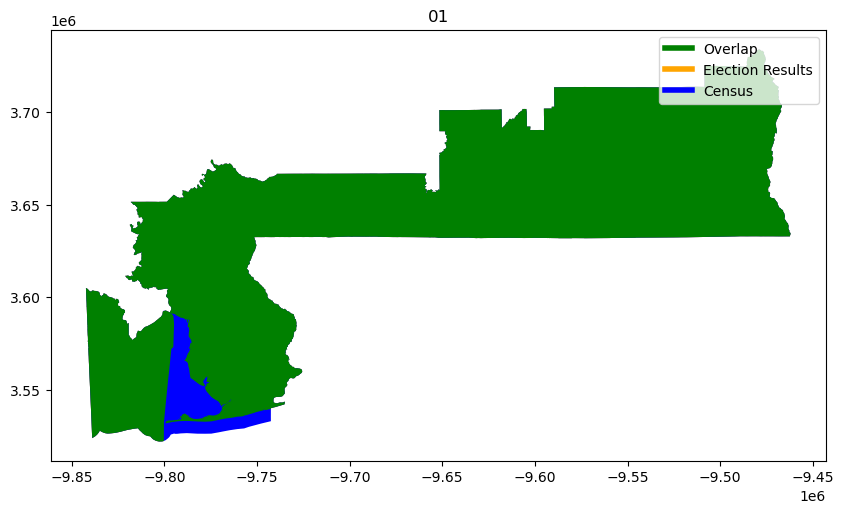

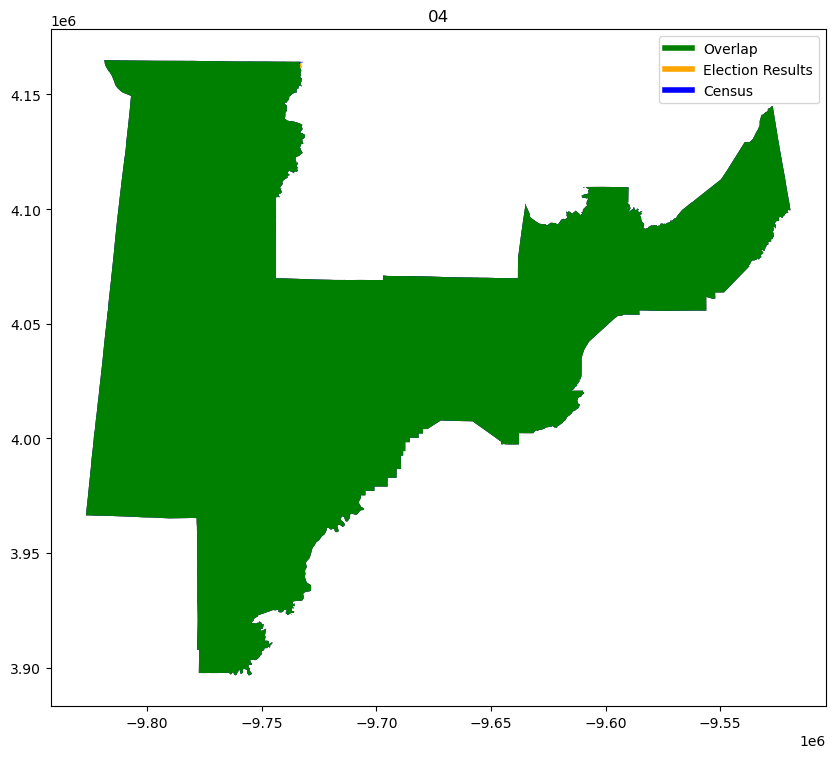

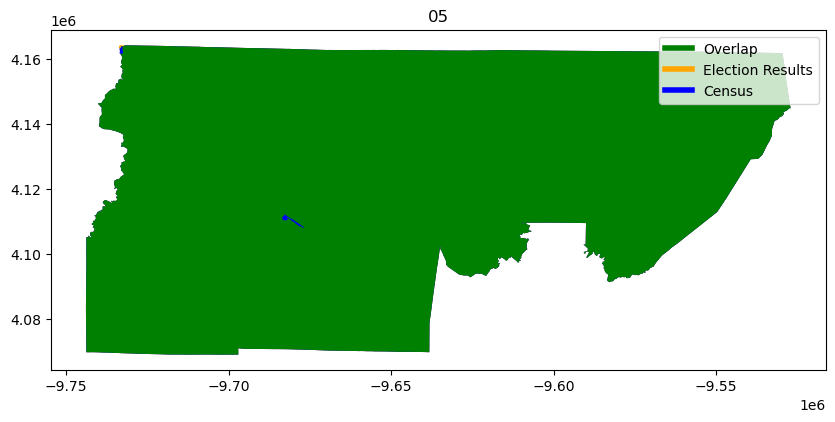

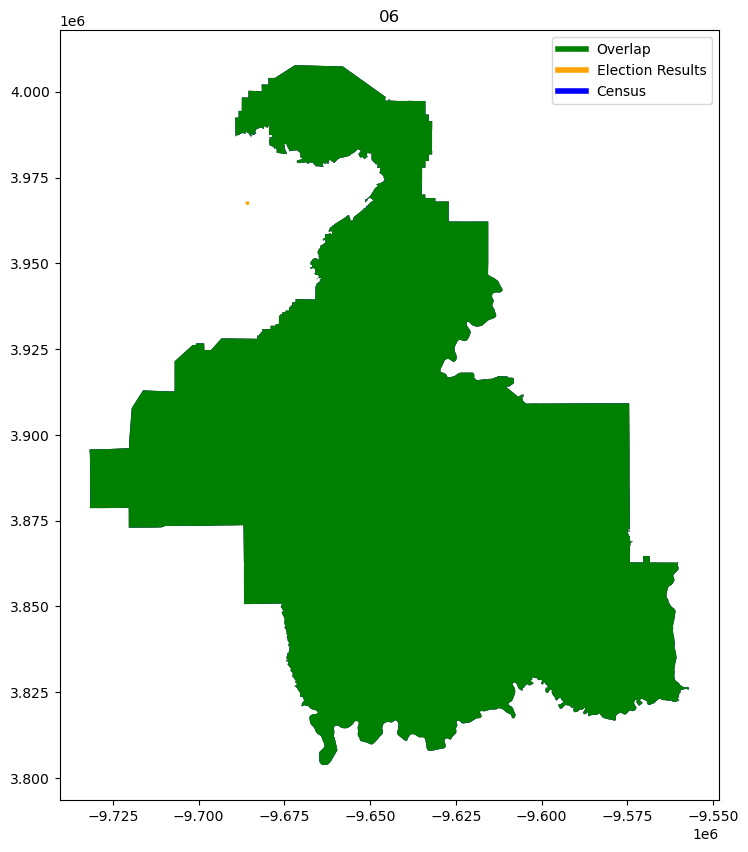

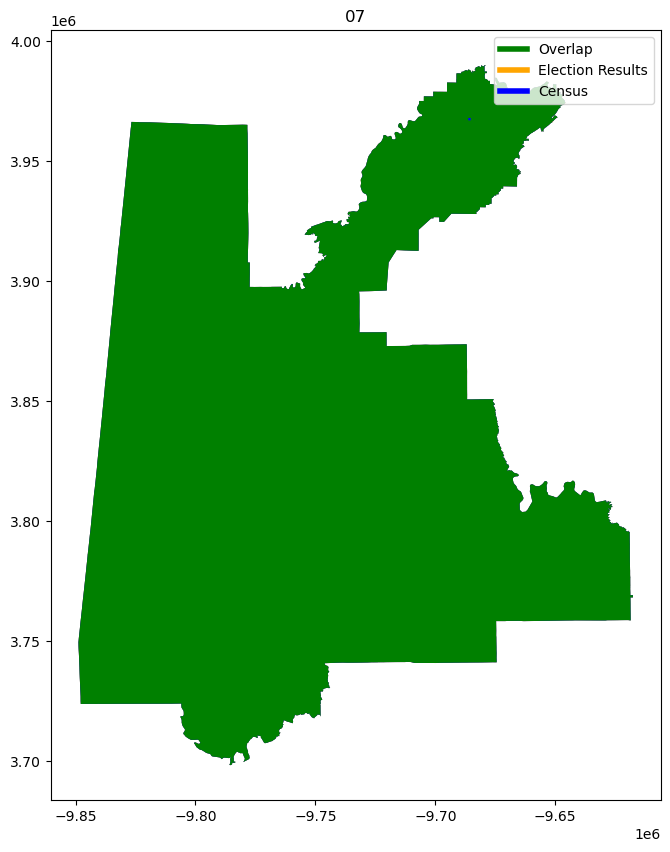

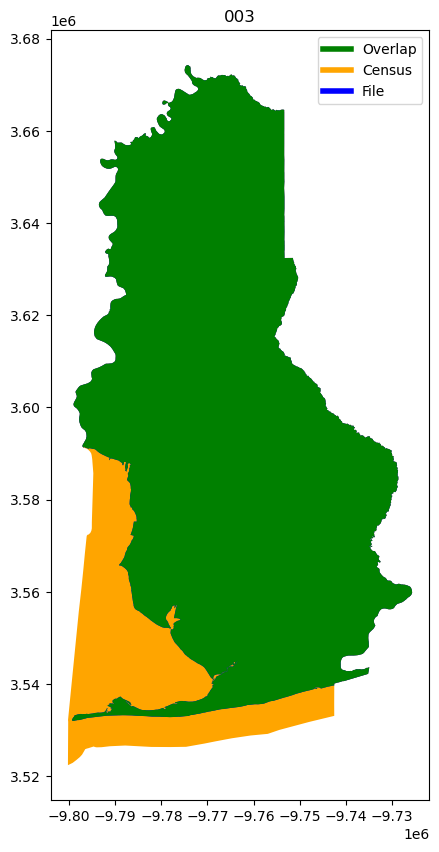

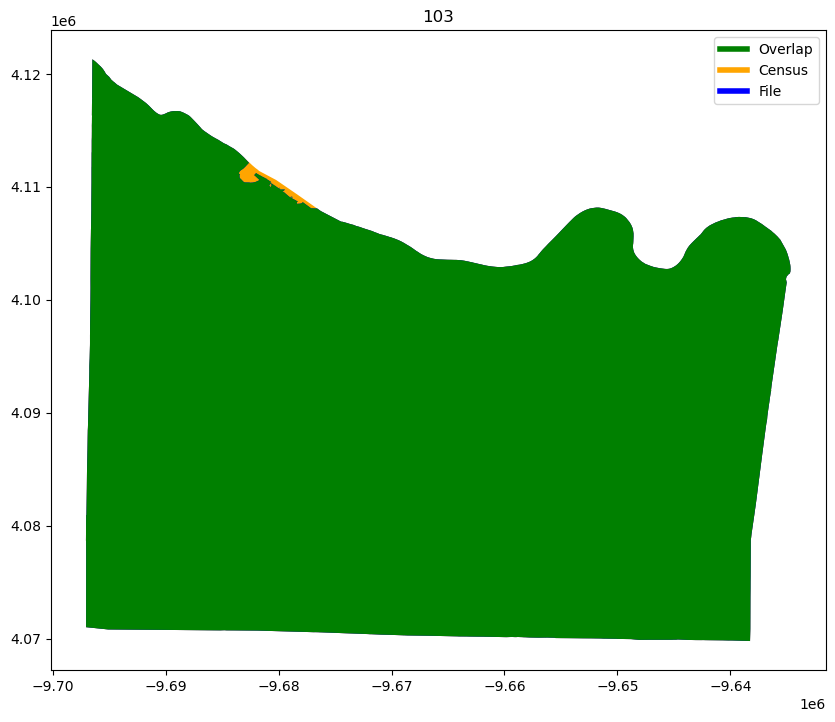

In [317]:

test_final["CONG_DIST"] = test_final["CONG_DIST"].astype(str).str.zfill(2)

al_cong_districts.rename(columns = {"DISTRICT":"CONG_DIST"}, inplace = True)

filtered_cong_results = test_final[~test_final["CONG_DIST"].isna()].dissolve("CONG_DIST")
filtered_cong_results.reset_index(inplace = True, drop = False)

al_cong_districts["CONG_DIST"] = al_cong_districts["CONG_DIST"].astype(str).str.zfill(2)



# Check implied SLDU districts based off of assignments against the actual ones
pdv.compare_geometries(filtered_cong_results, al_cong_districts ,"Election Results", "Census", "CONG_DIST","Districts",area_threshold=.1)




test_final.rename(columns = {"COUNTY_FIP":"COUNTYFP"}, inplace = True)

## Check Implied Parish Assignments

COUNTY_PATH = "/Users/peterhorton/Documents/RDH/raw_data/census/2020_TIGER_CNTY/al_cnty_2020_bound/al_cnty_2020_bound.shp"

al_counties = gp.read_file(COUNTY_PATH)
al_counties.rename(columns = {"COUNTYFP20":"COUNTYFP"}, inplace = True)
grouped_counties = test_final.dissolve("COUNTYFP")
grouped_counties.reset_index(inplace = True, drop = False)

pdv.compare_geometries(al_counties, grouped_counties, "Census", "File", "COUNTYFP", "County")






In [318]:
cong_cols = [i for i in list(test_final.columns) if "CON0" in i]

In [319]:
cong_cols

['PCON01RCAR',
 'PCON01RMOO',
 'PCON02DAVE',
 'PCON02DBRA',
 'PCON02DCOL',
 'PCON02DDAN',
 'PCON02DFIG',
 'PCON02DGIV',
 'PCON02DGRA',
 'PCON02DHAR',
 'PCON02DLEN',
 'PCON02DPAT',
 'PCON02DSIM',
 'PCON02RALB',
 'PCON02RBRE',
 'PCON02RDOB',
 'PCON02RDUP',
 'PCON02RGIL',
 'PCON02RHAR',
 'PCON02RSHE',
 'PCON02RTHO',
 'PCON03RBEV',
 'PCON03RNEW',
 'PCON03RROG',
 'PCON04RADE',
 'PCON04RHOL',
 'PCON06RMCF',
 'PCON06RPAL',
 'PCON06RWIL',
 'PCON07DDAV',
 'PCON07DSEW',
 'PCON07RHOR',
 'PCON07RLIT',
 'RCON02DDAN',
 'RCON02DFIG',
 'RCON02RBRE',
 'RCON02RDOB']

In [320]:
## Final File Cleaning and Export File

if not os.path.exists("./al_2024_prim_prec"):
    os.mkdir("./al_2024_prim_prec/")
    
if not os.path.exists("./al_2024_prim_prec/al_2024_prim_cong_prec"):
    os.mkdir("./al_2024_prim_prec/al_2024_prim_cong_prec")
if not os.path.exists("./al_2024_prim_prec/al_2024_prim_all_prec"):
    os.mkdir("./al_2024_prim_prec/al_2024_prim_all_prec")
    
        
test_final = gp.GeoDataFrame(test_final[['UNIQUE_ID',"COUNTYFP",
 'County',
 'Precinct',
'CONG_DIST']+cong_cols+["geometry"]])

test_final_unsplit = gp.GeoDataFrame(test_final_unsplit[['UNIQUE_ID',"COUNTYFP",
 'County',
 'Precinct']+race_cols+["geometry"]])




test_final.to_file("./al_2024_prim_prec/al_2024_prim_cong_prec/al_2024_prim_cong_prec.shp")
test_final_unsplit.to_file("./al_2024_prim_prec/al_2024_prim_all_prec/al_2024_prim_all_prec.shp")


# test_final["COUNTYFP"] = test_final["COUNTYFP"].astype(int).astype(str).str.zfill(3)

# results = test_final.drop(["geometry"], axis = 1)
# results.to_csv("./al_2024_prim_prec/al_2024_prim_prec.csv", index = False)




In [321]:
for file in os.listdir('./al_2024_prim_prec/'):
    print(file)


#os.remove('./al_2024_prim_prec/.DS_Store')

al_2024_prim_all_prec
README.txt
al_2024_prim_cong_prec


In [816]:
import shutil

shutil.make_archive('./al_2024_prim_prec/', 'zip', './al_2024_prim_prec/')

'/Users/peterhorton/Documents/RDH/pber_local/AL_2024/general/al_2024_gen_prec.zip'